###  EDA - Financial Anomaly Detection

**Goal:** Understand target distribution, data integrity, feature distributions, temporal patterns, and feature redundancy to guide preprocessing and modeling decisions.

## 1. Setup & Data Loading

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to DuckDB
conn = duckdb.connect("data/fraud.db")

# Load full joined data into pandas (this is ~590k rows, ~400 columns — fits in memory)
df = conn.execute("SELECT * FROM joined_transactions").fetchdf()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:20]}... (and more)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (590540, 434)
Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3']... (and more)


### 2. Plot 1 (Category 1 - Target)
 **Question:** What is the exact fraud percentage and does it require SMOTE?

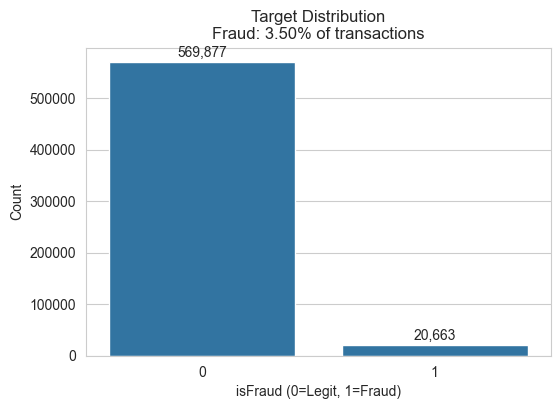

In [2]:
fraud_count = df['isFraud'].value_counts()
fraud_pct = (fraud_count[1] / len(df)) * 100

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title(f'Target Distribution\nFraud: {fraud_pct:.2f}% of transactions')
plt.xlabel('isFraud (0=Legit, 1=Fraud)')
plt.ylabel('Count')

# Annotate the bars
for i, v in enumerate(fraud_count.values):
    plt.text(i, v + 5000, f'{v:,}', ha='center', va='bottom')

plt.show()

In [ ]:
### Because of the severe class imbalance, we will apply SMOTE to oversample the minority class (fraudulent transactions) on the training set to help the model learn fraud patterns better.

### 3. Plot 2 (Category 2 - Integrity)
 **Question:** Which features have >40% missing and what is the overall missingness landscape?

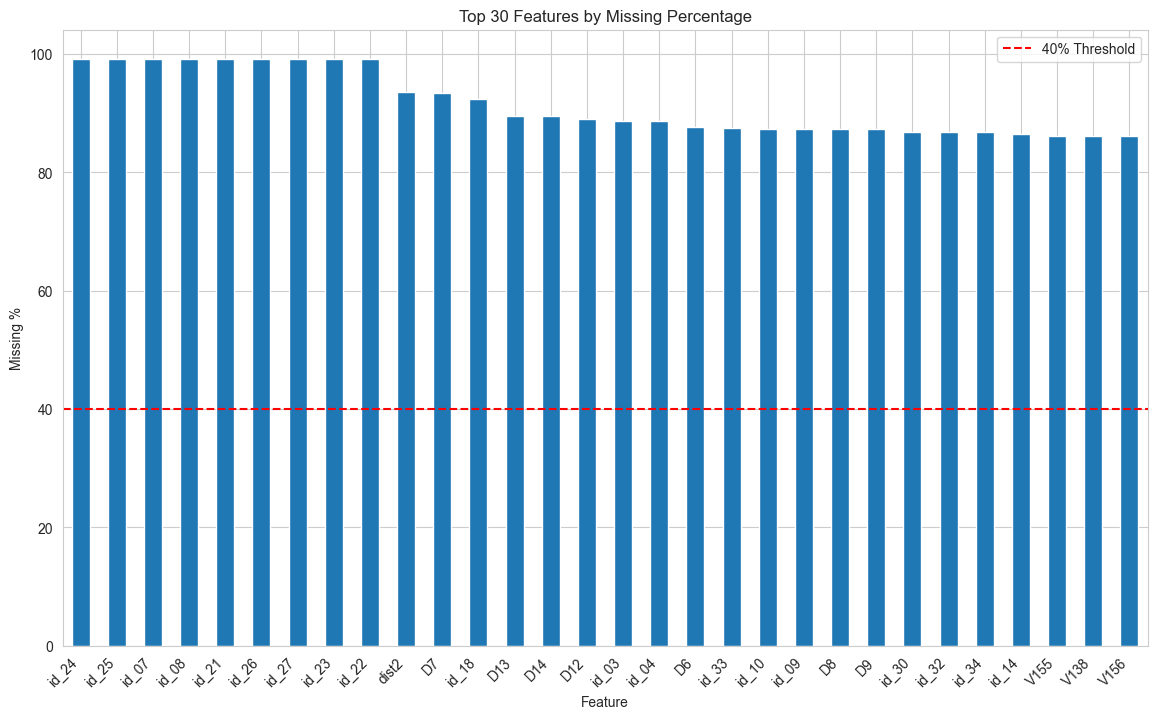

Number of features with >40% missing: 232


In [3]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(14, 8))
missing_percent.head(30).plot(kind='bar')
plt.title('Top 30 Features by Missing Percentage')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.axhline(y=40, color='r', linestyle='--', label='40% Threshold')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.show()

print(f"Number of features with >40% missing: {(missing_percent > 40).sum()}")

In [ ]:
### Due to extreme missingness (many features exceeding 85% missing values), we will drop features with more than 40% missing values to reduce dimensionality and eliminate noise.

### 4. Plot 3 (Category 2 - Integrity - Deep Dive)
 **Question:** Is missingness a signal of fraud? (Do fraud transactions have more missing values?)

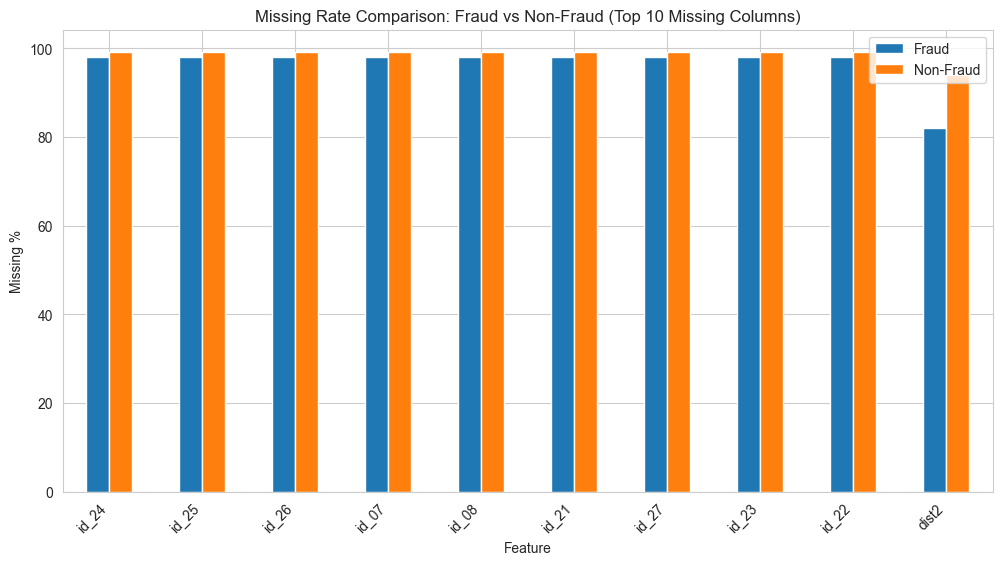

In [4]:
# Calculate missing % for fraud vs non-fraud for top 10 missing columns
top_missing_cols = missing_percent.head(10).index.tolist()

missing_fraud = df[df['isFraud'] == 1][top_missing_cols].isnull().mean() * 100
missing_nonfraud = df[df['isFraud'] == 0][top_missing_cols].isnull().mean() * 100

comparison_df = pd.DataFrame({
    'Fraud': missing_fraud,
    'Non-Fraud': missing_nonfraud
}).sort_values('Fraud', ascending=False)

comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Missing Rate Comparison: Fraud vs Non-Fraud (Top 10 Missing Columns)')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

In [ ]:
### Missing rates are virtually identical across both classes, except for features like dist2 where missingness is notably lower in fraudulent transactions, suggesting that the presence of data in these fields could be a valuable signal for detecting fraud.

### 5. Plot 4 (Category 3 - Distribution)
**Question:** Are fraud amounts significantly different, and is log-transform necessary?


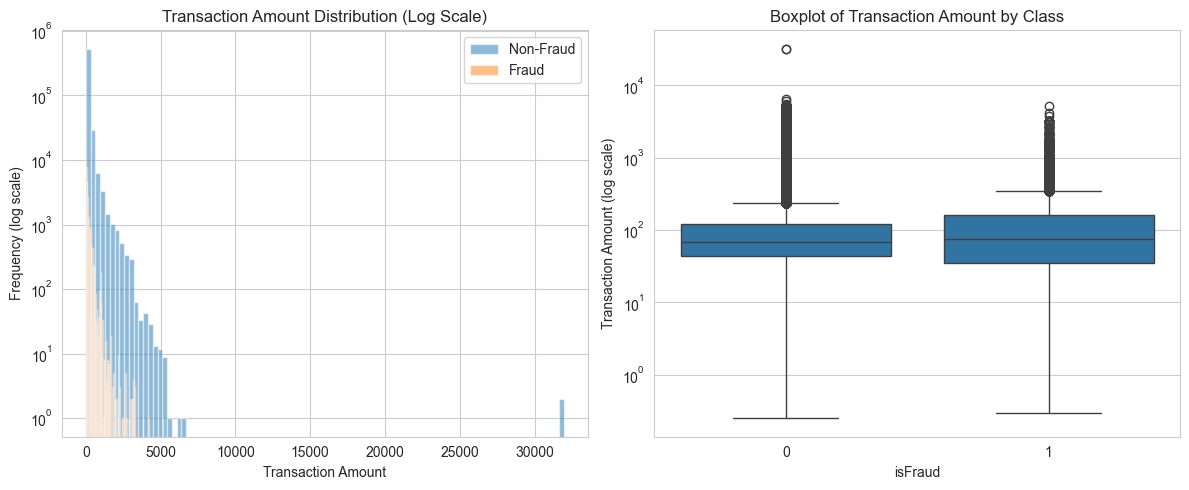

In [5]:
plt.figure(figsize=(12, 5))

# Subplot 1: Overlaid Histograms (Log Scale)
plt.subplot(1, 2, 1)
df[df['isFraud'] == 0]['TransactionAmt'].hist(bins=100, alpha=0.5, label='Non-Fraud', log=True)
df[df['isFraud'] == 1]['TransactionAmt'].hist(bins=100, alpha=0.5, label='Fraud', log=True)
plt.title('Transaction Amount Distribution (Log Scale)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.legend()

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.yscale('log')
plt.title('Boxplot of Transaction Amount by Class')
plt.xlabel('isFraud')
plt.ylabel('Transaction Amount (log scale)')

plt.tight_layout()
plt.show()

In [ ]:
### Fraudulent transactions show a slightly higher median amount than non-fraudulent ones, though both classes share heavily overlapping distributions; notably, extreme high-value outliers occur primarily in non-fraudulent transactions.

### 6. Plot 5 (Category 3 - Distribution - Outliers)
 **Question:** Are there extreme outliers unique to fraud?

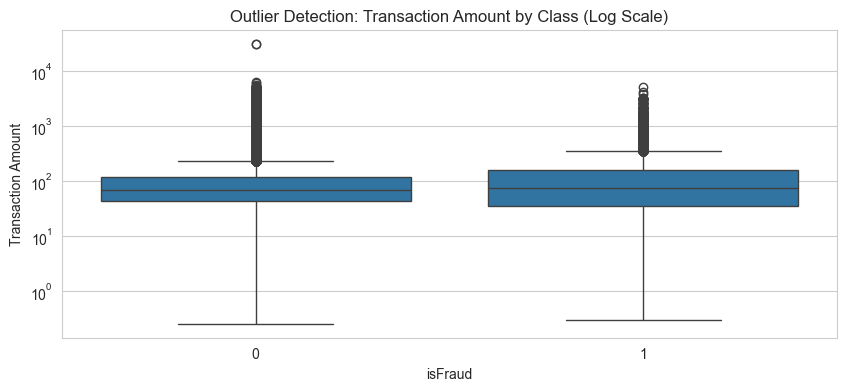

In [6]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='isFraud', y='TransactionAmt', data=df, showfliers=True)
plt.yscale('log')
plt.title('Outlier Detection: Transaction Amount by Class (Log Scale)')
plt.ylabel('Transaction Amount')
plt.xlabel('isFraud')
plt.show()

In [ ]:
### Extreme high-value outliers are actually more pronounced in non-fraudulent transactions, whereas fraudulent amounts plateau below $5,000 suggesting fraudsters may deliberately avoid ultra-large transactions to evade automated detection systems."

 ### 7. Plot 6 (Category 4 - Context - Time of Day)
 **Question:** Do frauds cluster at specific hours of the day?

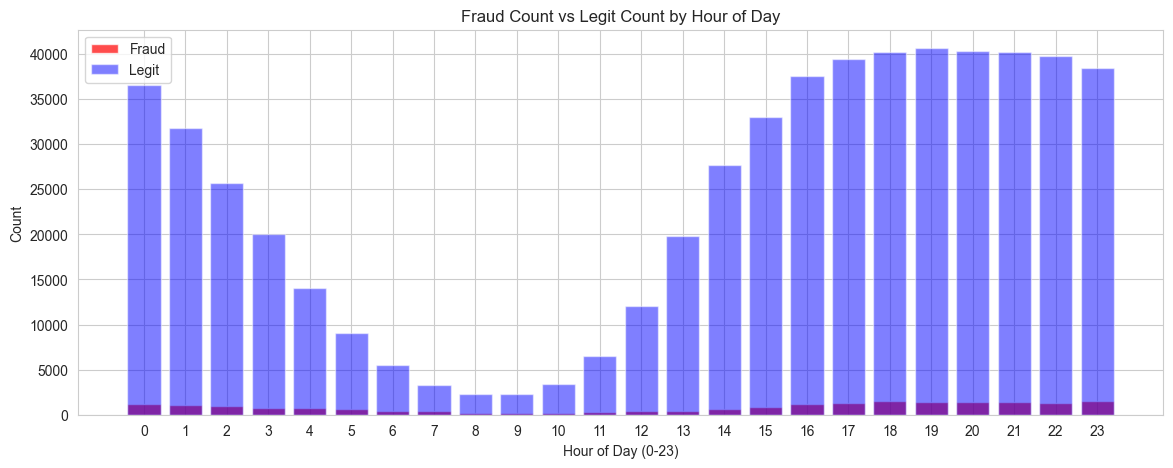

In [7]:
# Convert TransactionDT (seconds) to hour of day (0-23)
df['hour_of_day'] = (df['TransactionDT'] % 86400) // 3600

# Count frauds per hour
fraud_by_hour = df[df['isFraud'] == 1].groupby('hour_of_day').size()
legit_by_hour = df[df['isFraud'] == 0].groupby('hour_of_day').size()

plt.figure(figsize=(14, 5))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, alpha=0.7, label='Fraud', color='red', width=0.8)
plt.bar(legit_by_hour.index, legit_by_hour.values, alpha=0.5, label='Legit', color='blue', width=0.8)
plt.title('Fraud Count vs Legit Count by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Count')
plt.legend()
plt.xticks(range(0, 24))
plt.show()

In [ ]:
### While fraudulent transaction counts remain relatively stable throughout the day, legitimate activity drops significantly during early morning hours (approx. 4–9 AM)—making the fraud rate (ratio) much higher during quiet night hours and highlighting time of day as a useful risk factor.

### 8. Plot 7 (Category 4 - Context - Day of Week)
 **Question:** Are weekends riskier than weekdays?


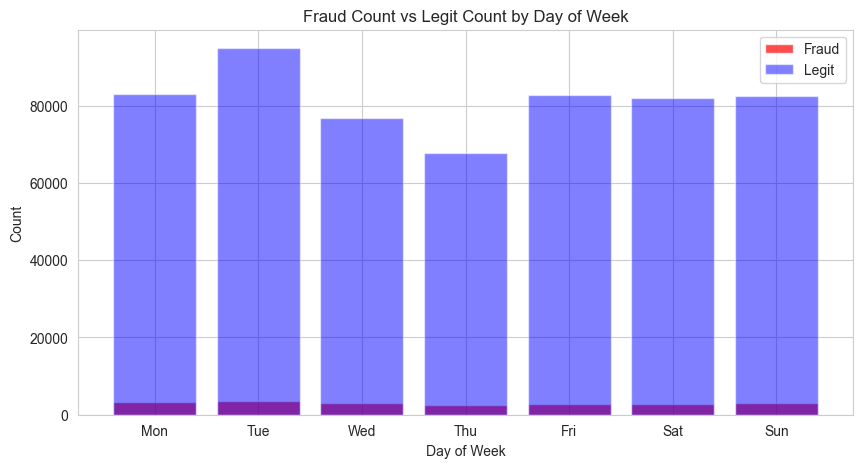

In [8]:
# Convert seconds to day of week (0=Monday, 6=Sunday)
# Since TransactionDT is seconds, we need days since reference. We can't know the exact absolute date,
# but we can compute day_of_week relative to the start. We just need the modulo 604800 (7*86400) and divide by 86400.
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7  # 0=Monday, 6=Sunday (relative)

fraud_by_dow = df[df['isFraud'] == 1].groupby('day_of_week').size()
legit_by_dow = df[df['isFraud'] == 0].groupby('day_of_week').size()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))
plt.bar(days, fraud_by_dow.values, alpha=0.7, label='Fraud', color='red')
plt.bar(days, legit_by_dow.values, alpha=0.5, label='Legit', color='blue')
plt.title('Fraud Count vs Legit Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
### Legitimate transactions fluctuate across weekdays with a peak on Tuesday and dips on Wednesday/Thursday, whereas fraudulent transactions stay nearly constant every day of the week.

 ### 9. Plot 8 (Category 3 - Redundancy)
**Question:** Are V-features highly correlated, justifying PCA?

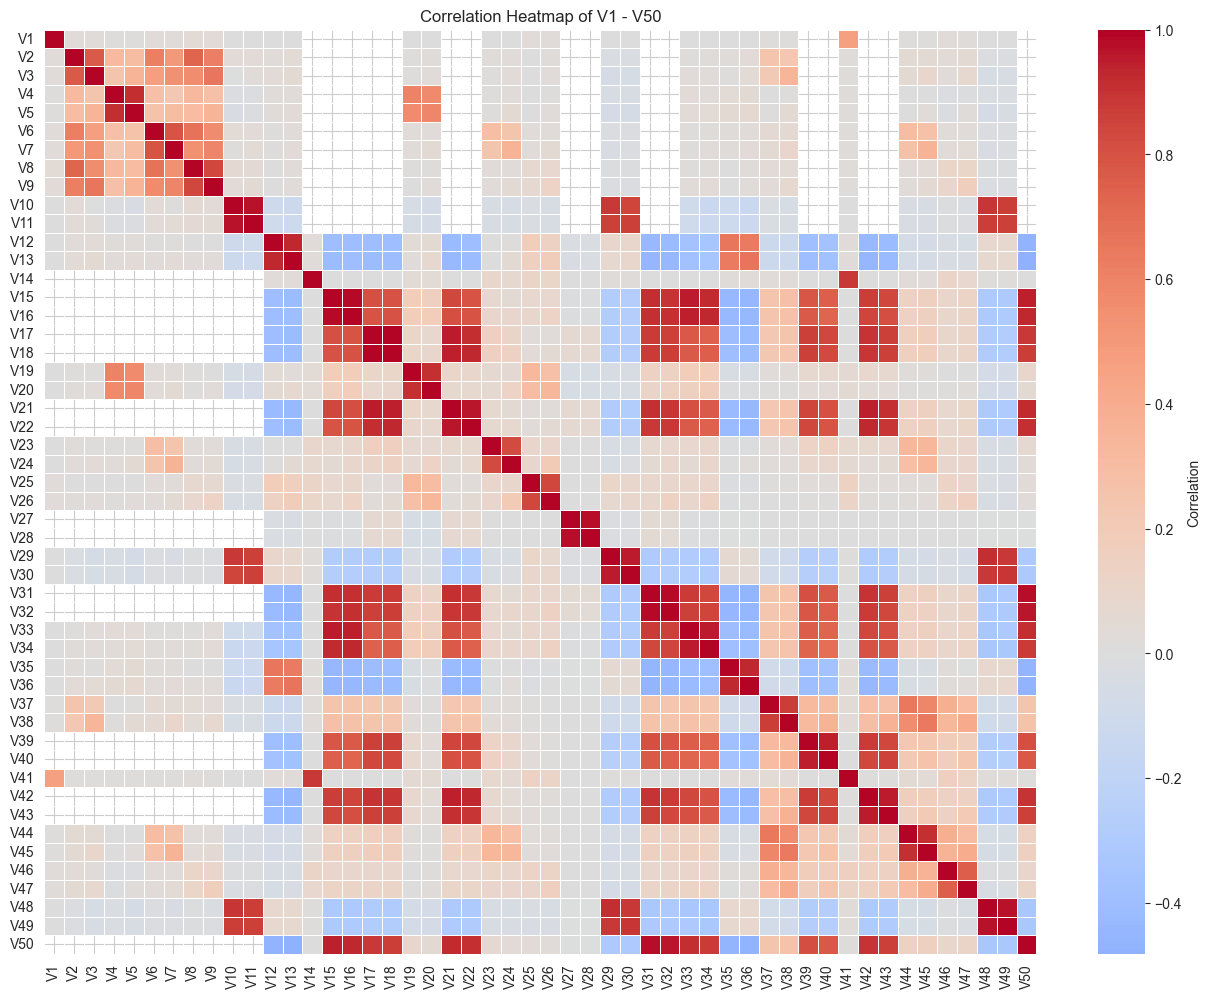

In [9]:
# Sample first 50 V-features for heatmap (V1 to V50)
v_cols = [f'V{i}' for i in range(1, 51)]
v_subset = df[v_cols]

# Compute correlation matrix
corr_matrix = v_subset.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of V1 - V50')
plt.show()


In [ ]:
### The heatmap reveals strong blocks of multicollinearity—particularly among features V15–V18, V21–V22, V31–V34, and V48–V50—indicating significant feature redundancy that may benefit from dimensionality reduction (like PCA) or regularized models.

### 10. Summary & Action Items for Session 3 (Cleanlab + SMOTE)

* **Target Imbalance:** Fraud accounts for only 3.50% of all transactions (20,663 vs 569,877 legitimate) -> apply SMOTE strictly to the training set or set `scale_pos_weight` to handle class imbalance.

* **Missing Data:** Top features (such as `id_24`, `id_25`, `dist2`) have >85% missing values, far exceeding the 40% threshold -> drop features with >40% missing data to eliminate noise and reduce dimensionality.
* **Missingness Signal:** `dist2` is missing in ~98% of non-fraud cases but ~82% of fraud cases -> keep missingness as a binary indicator feature because the presence of data serves as a strong fraud signal.
* **Transaction Amount:** The distribution is heavily right-skewed with extreme non-fraud outliers up to ~$30,000 -> apply a log transformation to normalize the scale and stabilize model training.
* **Outlier Handling:** Fraudulent transactions plateau around $5,000, while non-fraud contains the most extreme high-value outliers -> leave outliers intact or handle carefully, as ultra-high values strongly correlate with legitimate transactions.
* **Time Features (Hour of Day):** Legitimate activity drops significantly between 4 AM and 9 AM while fraud remains steady -> engineer `hour_of_day` to capture the higher fraud-to-legit ratio during off-peak night hours.
* **Time Features (Day of Week):** Legitimate activity fluctuates across weekdays (peaking on Tuesday) while fraud volume stays nearly uniform -> engineer `day_of_week` to capture daily baseline patterns.
* **V-Features Correlation:** Heatmap shows strong blocks of collinearity (e.g., V15–V18, V21–V22, V31–V34, V48–V50) -> proceed with PCA or feature selection to remove redundancy.

### 11. Cleanup

In [10]:
conn.close()